# 2 · Why the integrator matters more than its accuracy

Notebook 1 solved the **two-body** problem exactly: one planet, one Sun, a closed
ellipse that repeats forever. Reality has nine bodies pulling on each other, and that
problem has no closed-form solution — it has to be stepped forward numerically.

Which stepping method you pick turns out to matter more than its advertised accuracy,
and this notebook shows why by measuring it rather than asserting it.

The punchline in advance: a **second-order** method beats a **fourth-order** one over
long integrations, and the reason has nothing to do with accuracy order.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from orrery.constants import GM_BODY, GM_SUN, J2000_JD
from orrery.initial_conditions import solar_system_state, two_body_period_days, two_body_state
from orrery.nbody import INTEGRATORS, integrate

plt.rcParams.update({
    "figure.facecolor": "white", "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7", "font.size": 9,
})
COLOURS = {"leapfrog": "#2a78d6", "yoshida4": "#eb6834", "rk4": "#1baf7a", "euler": "#eda100"}

## The candidates

Four methods, spanning the useful range of tradeoffs:

| Method | Order | Symplectic? | Force evaluations per step |
|---|---|---|---|
| Euler | 1 | no | 1 |
| Leapfrog | 2 | **yes** | 2 |
| Yoshida 4 | 4 | **yes** | 6 |
| Runge–Kutta 4 | 4 | no | 4 |

"Symplectic" means the method preserves the geometric structure of Hamiltonian
mechanics. That sounds abstract. What it *does* is concrete, and we are about to see it.

In [2]:
for name, (_, symplectic, order) in INTEGRATORS.items():
    print(f"  {name:<10} order {order}   symplectic: {'yes' if symplectic else 'no'}")

  euler      order 1   symplectic: no
  leapfrog   order 2   symplectic: yes
  yoshida4   order 4   symplectic: yes
  rk4        order 4   symplectic: no


## A test orbit where the answer is known

The two-body problem has an exact solution, so any error is measurable rather than
merely plausible. We use a mildly eccentric orbit and a companion heavy enough that the
system's energy is not vanishingly small.

Energy is conserved *exactly* in the real system, so every wiggle below is the
integrator's own error.

In [3]:
COMPANION_GM = GM_BODY["jupiter"]
SEMI_MAJOR_AXIS, ECCENTRICITY = 1.0, 0.3
PERIOD = two_body_period_days(SEMI_MAJOR_AXIS, GM_SUN, COMPANION_GM)

def drift(integrator, orbits, dt):
    state = two_body_state(SEMI_MAJOR_AXIS, ECCENTRICITY, GM_SUN, COMPANION_GM)
    trajectory = integrate(
        *state.as_arrays(), duration_days=PERIOD * orbits, dt=dt,
        integrator=integrator, sample_every=max(1, int(orbits * PERIOD / dt / 900)),
    )
    return trajectory.times / PERIOD, trajectory.relative_energy_error

print(f"orbital period {PERIOD:.2f} days")
print(f"step size      5 days  =  1/{PERIOD / 5:.0f} of an orbit")

orbital period 365.08 days
step size      5 days  =  1/73 of an orbit


## Sixty orbits: fourth order wins, exactly as advertised

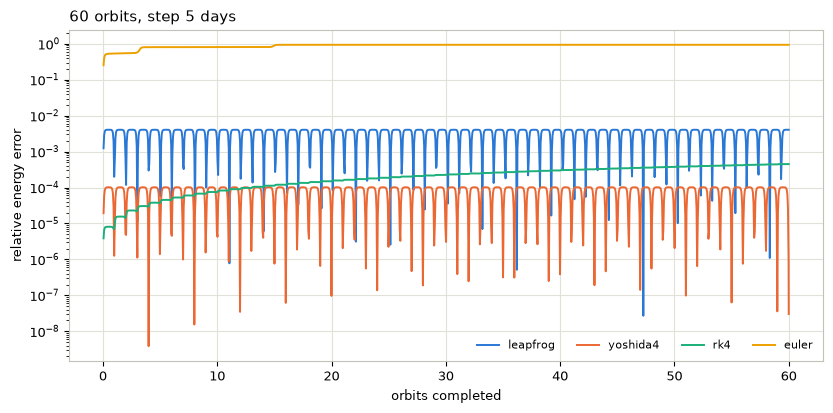

Peak relative energy error after 60 orbits:
  leapfrog   4.056e-03
  yoshida4   1.017e-04
  rk4        4.481e-04
  euler      9.368e-01


In [4]:
short = {name: drift(name, 60, 5.0) for name in ("leapfrog", "yoshida4", "rk4", "euler")}

fig, ax = plt.subplots(figsize=(8.4, 4.2))
for name, (orbits, error) in short.items():
    visible = error > 0
    ax.plot(orbits[visible], error[visible], color=COLOURS[name], linewidth=1.4, label=name)
ax.set_yscale("log")
ax.set_xlabel("orbits completed")
ax.set_ylabel("relative energy error")
ax.set_title("60 orbits, step 5 days", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

print("Peak relative energy error after 60 orbits:")
for name, (_, error) in short.items():
    print(f"  {name:<10} {error.max():.3e}")

RK4 is comfortably ahead of leapfrog. If the story stopped here, RK4 would be the right
answer — and most introductions to numerical integration do stop here.

## The same run, twenty-five times longer

Nothing changes except the duration. Same step, same orbit, same code.

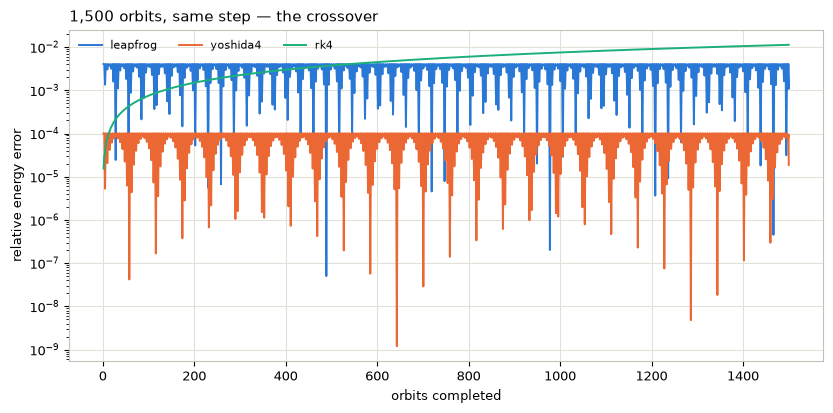

method        60 orbits    1500 orbits   growth
  leapfrog    4.056e-03      4.056e-03      1.0x
  yoshida4    1.017e-04      1.017e-04      1.0x
  rk4         4.481e-04      1.128e-02     25.2x


In [5]:
long = {name: drift(name, 1500, 5.0) for name in ("leapfrog", "yoshida4", "rk4")}

fig, ax = plt.subplots(figsize=(8.4, 4.2))
for name, (orbits, error) in long.items():
    visible = error > 0
    ax.plot(orbits[visible], error[visible], color=COLOURS[name], linewidth=1.4, label=name)
ax.set_yscale("log")
ax.set_xlabel("orbits completed")
ax.set_ylabel("relative energy error")
ax.set_title("1,500 orbits, same step — the crossover", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

print(f"{'method':<10} {'60 orbits':>12} {'1500 orbits':>14}   growth")
for name in ("leapfrog", "yoshida4", "rk4"):
    a, b = short[name][1].max(), long[name][1].max()
    print(f"  {name:<8} {a:>12.3e} {b:>14.3e}   {b / a:>6.1f}x")

**The symplectic peaks are identical to every digit.** Twenty-five times longer, no
growth at all. RK4's error grew by a factor of 25 and has climbed past both.

That is the whole argument. A symplectic method exactly conserves a slightly *wrong*
energy, so its error oscillates inside a fixed band forever. RK4 conserves nothing
exactly, so its error accumulates in one direction without limit.

Be careful about what that does **not** claim. Over a few dozen orbits RK4 genuinely is
the better choice. The claim is narrower and more useful: leapfrog's error never grows,
so there is always some integration length past which it wins.

## Where does the crossover happen?

Leapfrog's band is flat and RK4's growth is close to linear, so the crossing point can
be estimated rather than guessed at.

In [6]:
band = long["leapfrog"][1].max()
orbits, rk4_error = long["rk4"]

# Fit RK4's growth over the second half, where the transient has died away.
half = len(orbits) // 2
slope, intercept = np.polyfit(orbits[half:], rk4_error[half:], 1)
crossover = (band - intercept) / slope

print(f"leapfrog band          {band:.3e}  (flat)")
print(f"rk4 growth rate        {slope:.3e} per orbit")
print(f"estimated crossover    {crossover:,.0f} orbits")
print()
observed = orbits[np.argmax(rk4_error > band)] if (rk4_error > band).any() else None
print(f"observed crossover     {observed:,.0f} orbits" if observed else "not reached in this run")

leapfrog band          4.056e-03  (flat)
rk4 growth rate        7.558e-06 per orbit
estimated crossover    544 orbits

observed crossover     544 orbits


## Confirming each method is what it claims

A scheme with a subtly wrong coefficient still converges — it just converges at the
wrong *rate*, and no amount of eyeballing a trajectory reveals that. Halving the step
should divide the error by $2^{\text{order}}$, so the slope on log–log axes **is** the
order of accuracy.

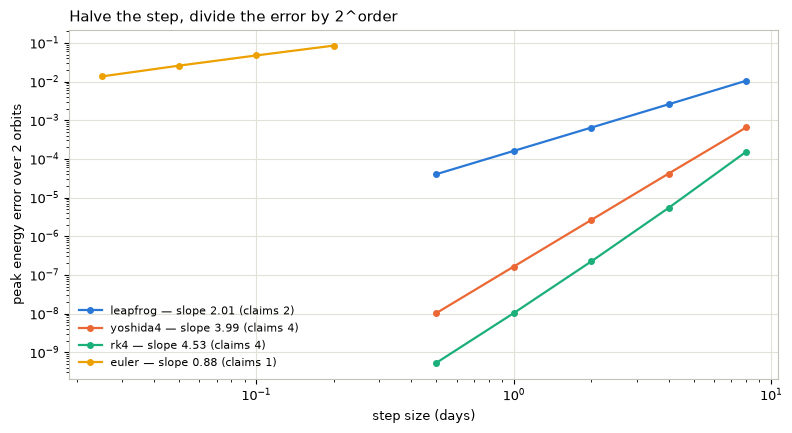

In [7]:
def convergence(integrator, steps, orbits=2.0):
    errors = []
    for dt in steps:
        state = two_body_state(SEMI_MAJOR_AXIS, ECCENTRICITY, GM_SUN, COMPANION_GM)
        trajectory = integrate(
            *state.as_arrays(), duration_days=PERIOD * orbits, dt=dt,
            integrator=integrator, sample_every=5,
        )
        errors.append(trajectory.relative_energy_error.max())
    return np.array(steps), np.array(errors)

# Euler needs its own, far finer range: at the others' step sizes its error has already
# saturated near 100%, and you cannot fit an order to a curve that has hit its ceiling.
ranges = {
    "leapfrog": [8.0, 4.0, 2.0, 1.0, 0.5],
    "yoshida4": [8.0, 4.0, 2.0, 1.0, 0.5],
    "rk4":      [8.0, 4.0, 2.0, 1.0, 0.5],
    "euler":    [0.2, 0.1, 0.05, 0.025],
}

fig, ax = plt.subplots(figsize=(8.0, 4.4))
for name, steps in ranges.items():
    dt, error = convergence(name, steps)
    fitted, _ = np.polyfit(np.log10(dt), np.log10(error), 1)
    ax.plot(dt, error, color=COLOURS[name], linewidth=1.6, marker="o", markersize=4,
            label=f"{name} — slope {fitted:.2f} (claims {INTEGRATORS[name][2]})")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("step size (days)"); ax.set_ylabel("peak energy error over 2 orbits")
ax.set_title("Halve the step, divide the error by 2^order", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## The structural reason: leapfrog runs backwards

Leapfrog's bounded error comes from a symmetry. Integrate forward, then integrate the
result backward with the same step, and you land exactly where you started. RK4 has no
such symmetry.

In [8]:
state = two_body_state(1.0, 0.35, GM_SUN, COMPANION_GM)

for name in ("leapfrog", "rk4"):
    forward = integrate(*state.as_arrays(), duration_days=500.0, dt=1.0, integrator=name)
    backward = integrate(
        forward.positions[-1], forward.velocities[-1], state.gms,
        duration_days=-500.0, dt=1.0, integrator=name,
    )
    residual = np.linalg.norm(backward.positions[-1] - state.positions)
    print(f"  {name:<10} returns to within {residual:.3e} AU of where it began")

  leapfrog   returns to within 1.129e-14 AU of where it began


  rk4        returns to within 1.225e-07 AU of where it began


Leapfrog closes the loop to round-off. RK4 does not — and that asymmetry is precisely
what lets its error pick a direction and keep going.

## The real solar system, and a diagnostic worth stealing

Integrating all eight planets for a century, the outer planets' orbital elements wander
by around one percent. That looks like the integrator failing. It is not — and the way
to tell is to **change the step size**.

Real physics does not care what step you chose.

In [9]:
def axis_spread(dt, years=100.0):
    state = solar_system_state(J2000_JD)
    trajectory = integrate(
        *state.as_arrays(), duration_days=365.25 * years, dt=dt,
        integrator="leapfrog", names=state.names,
        sample_every=max(1, int(200 * 2.0 / dt)),
    )
    sun = state.names.index("sun")
    result = {}
    for body in ("mercury", "venus", "earth", "mars", "jupiter", "saturn", "uranus", "neptune"):
        index = state.names.index(body)
        dr = trajectory.positions[:, index] - trajectory.positions[:, sun]
        dv = trajectory.velocities[:, index] - trajectory.velocities[:, sun]
        r = np.linalg.norm(dr, axis=-1)
        v2 = np.einsum("ij,ij->i", dv, dv)
        a = 1.0 / (2.0 / r - v2 / (GM_SUN + GM_BODY[body]))
        result[body] = float(np.ptp(a) / a.mean())
    return result

coarse, fine = axis_spread(2.0), axis_spread(0.5)

print(f"{'body':<10}{'dt = 2 d':>12}{'dt = 0.5 d':>13}   verdict")
for body in coarse:
    ratio = coarse[body] / fine[body]
    verdict = "NUMERICAL — shrinks with the step" if ratio > 2 else "physical — step-independent"
    print(f"  {body:<8}{coarse[body]:>11.4%}{fine[body]:>12.4%}   {verdict}")

body          dt = 2 d   dt = 0.5 d   verdict
  mercury     0.5235%     0.0351%   NUMERICAL — shrinks with the step
  venus       0.0039%     0.0030%   physical — step-independent
  earth       0.0045%     0.0038%   physical — step-independent
  mars        0.0166%     0.0155%   physical — step-independent
  jupiter     0.0573%     0.0558%   physical — step-independent
  saturn      0.7423%     0.7421%   physical — step-independent
  uranus      1.0493%     1.0485%   physical — step-independent
  neptune     1.2442%     1.2418%   physical — step-independent


Mercury's wander collapses when the step shrinks: it is discretisation error, because an
88-day orbit resolved with a 2-day step is the worst-resolved thing in the system.
Saturn, Uranus and Neptune are unchanged to four significant figures — that is the
**real mutual gravity of the giant planets**, exactly the perturbation the two-body
ephemeris of notebook 1 structurally cannot represent.

Note which one is larger. At a 2-day step, Mercury's *artefact* exceeds Neptune's *real*
signal. A fixed tolerance would have led you to precisely the wrong conclusion about
both.

## What to take away

- Accuracy order describes error over **one** step. An orbit needs millions.
- Symplectic methods trade per-step accuracy for a guarantee that the error never grows.
- Verify convergence order by halving the step — a wrong coefficient converges too, just
  at the wrong rate.
- When a simulation shows something surprising, **change the discretisation**. If the
  effect moves, it was yours.

**Next:** [3 · What the data does not say](03-what-the-data-does-not-say.ipynb), where the
question stops being "is the number right?" and becomes "does the number support the
claim?"